In [30]:
#import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Read documents
df = pd.read_csv('vgchartz-2024.csv')

In [15]:
# print firsts information
df

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64011,/games/boxart/full_2779838AmericaFrontccc.jpg,XBlaze Lost: Memories,PC,Visual Novel,Aksys Games,Arc System Works,NaN,NaN,NaN,NaN,NaN,NaN,2016-08-11,2019-01-28
64012,/games/boxart/full_8031506AmericaFrontccc.jpg,"Yoru, Tomosu",PS4,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64013,/games/boxart/full_6553045AmericaFrontccc.jpg,"Yoru, Tomosu",NS,Visual Novel,Nippon Ichi Software,Nippon Ichi Software,NaN,NaN,NaN,NaN,NaN,NaN,2020-07-30,2020-05-09
64014,/games/boxart/full_6012940JapanFrontccc.png,Yunohana SpRING! ~Mellow Times~,NS,Visual Novel,Idea Factory,Otomate,NaN,NaN,NaN,NaN,NaN,NaN,2019-02-28,2019-02-24


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [20]:
df.shape

(64016, 14)

In [18]:

df.sample(5)

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
136,/games/boxart/full_8811836AmericaFrontccc.jpg,Frogger,PS,Action,Hasbro Interactive,Millenium Interactive,NaN,4.16,3.79,NaN,0.27,0.11,1997-09-30,NaN
61152,/games/boxart/full_magi_344AmericaFront.jpg,MAGI,PC,Strategy,MoaCube,MoaCube,NaN,NaN,NaN,NaN,NaN,NaN,2007-05-29,2019-04-16
28211,/games/boxart/full_7708758AmericaFrontccc.jpg,Game of Thrones: Episode One - Iron From Ice,X360,Adventure,Unknown,Telltale Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-08-23
33736,/games/boxart/default.jpg,Culture Quiz,PSN,Misc,Sony Computer Entertainment,Relentless Software,NaN,NaN,NaN,NaN,NaN,NaN,2010-08-11,NaN
60398,/games/boxart/full_9125939AmericaFrontccc.jpg,Winter Olympic Games: Lillehammer '94,GG,Sports,Sega,Unexpected Development,NaN,NaN,NaN,NaN,NaN,NaN,1994-01-01,NaN


In [17]:
df.isnull().sum()

img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [21]:
# Cria um novo DataFrame apenas com jogos que possuem o valor de total_sales
df_vendas = df.dropna(subset=['total_sales'])

print(f"Sobraram {len(df_vendas)} jogos com dados de vendas.")

Sobraram 18922 jogos com dados de vendas.


In [22]:
df['total_sales'] = df['total_sales'].fillna(0)

In [27]:
# Verificar quantos duplicados existem
print(df.duplicated().sum())

0


C:\Users\thaia\AppData\Local\Temp\ipykernel_27672\3007874407.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_other_sales, x='publisher', y='other_sales', palette='magma')


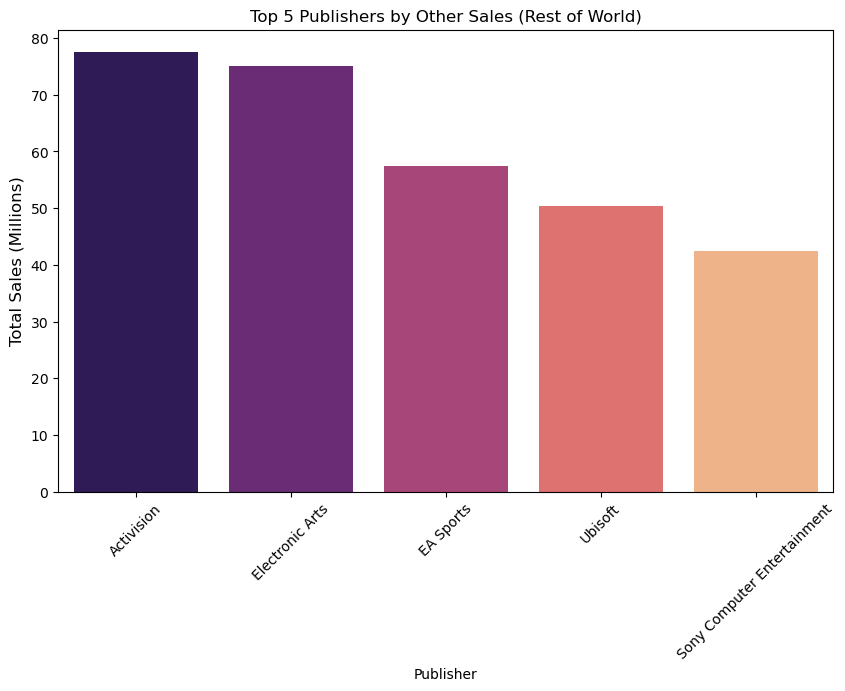

In [33]:
# Preenchendo valores nulos de vendas com 0
df['other_sales'] = df['other_sales'].fillna(0)

# 2. Processamento (Feature Engineering / Wrangling)
# Agrupando por editora e somando as vendas de 'other_sales'
top_5_other_sales = df.groupby('publisher')['other_sales'].sum().nlargest(5).reset_index()

# 3. Visualização Estática (Gráfico de Barras)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_5_other_sales, x='publisher', y='other_sales', palette='magma')

# Customização de design (exigido no Part 3)
plt.title('Top 5 Publishers by Other Sales (Rest of World)', fontsize=12)
plt.ylabel('Total Sales (Millions)', fontsize=12)
plt.xlabel('Publisher', fontsize=10)
plt.xticks(rotation=45) # Inclina os nomes para não sobrepor

plt.show()